Name : Divykumar Jadhav 


Domain : AI/ML


Task 1 :Topic: Linear Regression Model (California Housing Dataset) 

In [2]:
# Import libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Train-test split
from sklearn.model_selection import train_test_split

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Save model
import joblib

In [3]:
# Load California Housing dataset

housing = fetch_california_housing(as_frame=True)

# Features
X = housing.data

# Target variable
y = housing.target

# Combine into dataframe
df = pd.concat([X, y.rename("MedHouseVal")], axis=1)

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Shape of dataset

df.shape

(20640, 9)

In [5]:
# Column names

df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [6]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
# Statistical summary

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
# Missing values

df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

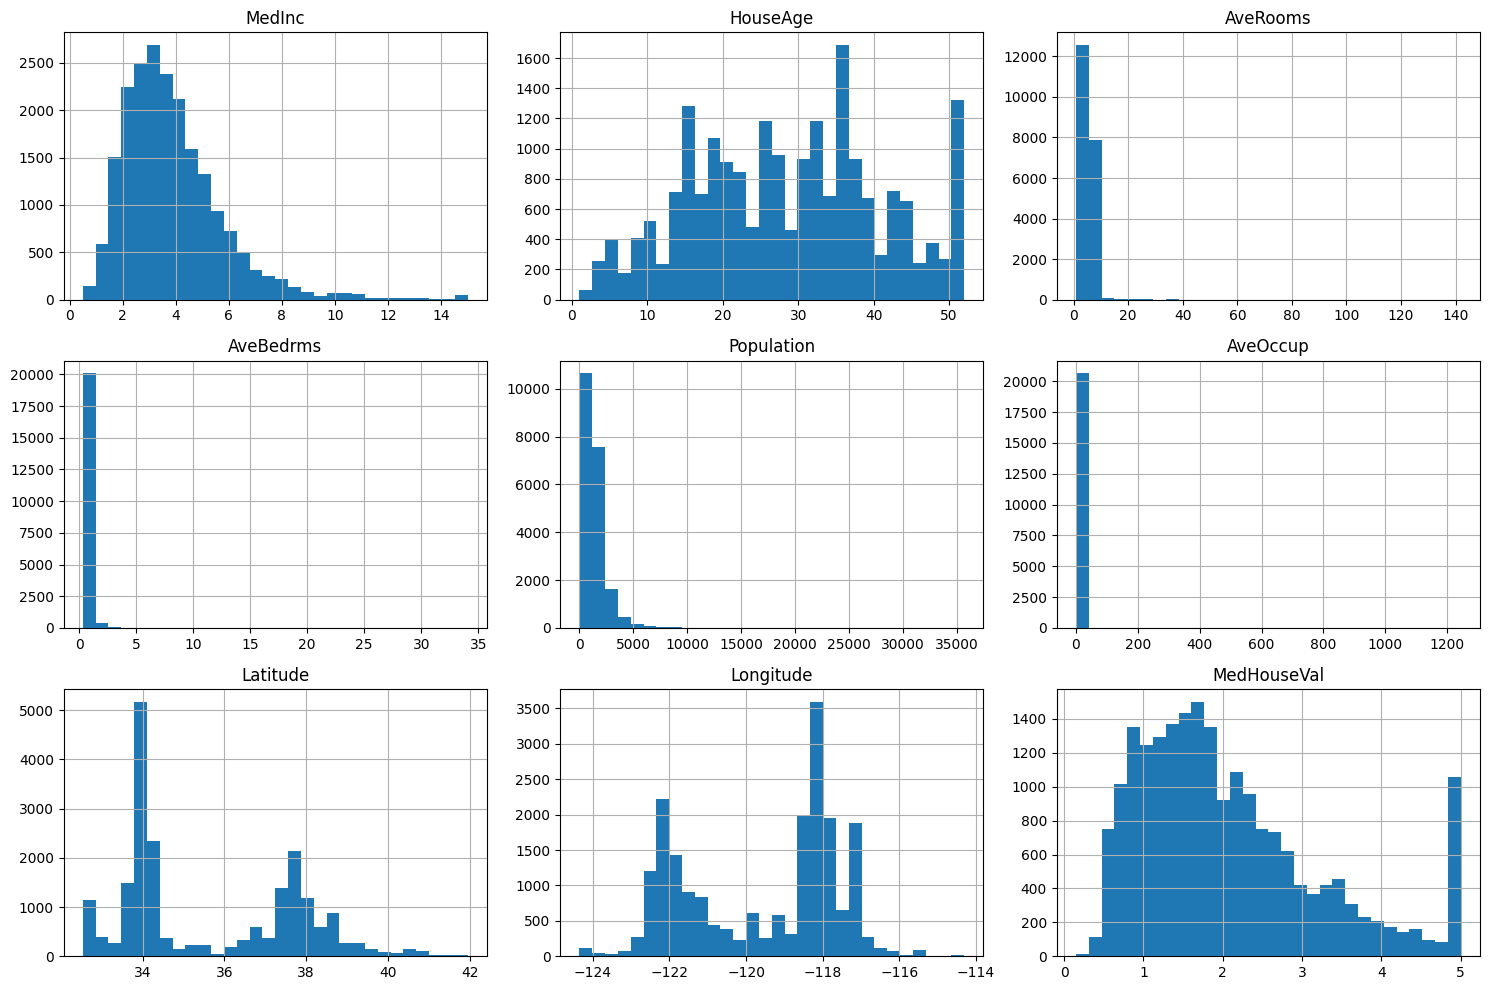

In [9]:
# Histogram plots

df.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

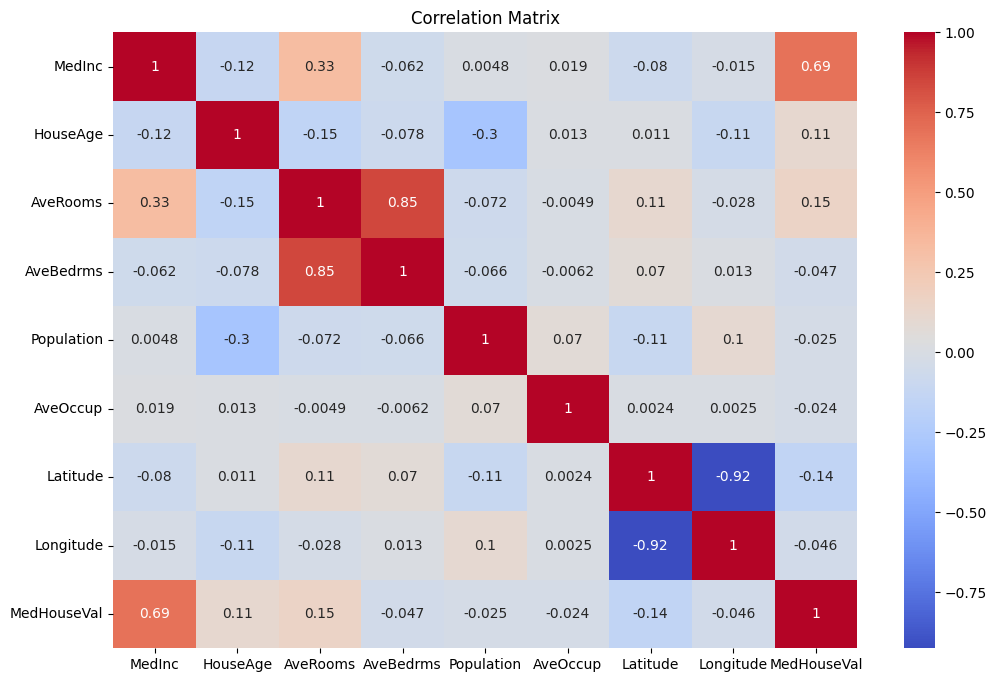

In [10]:
# Correlation matrix

corr_matrix = df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

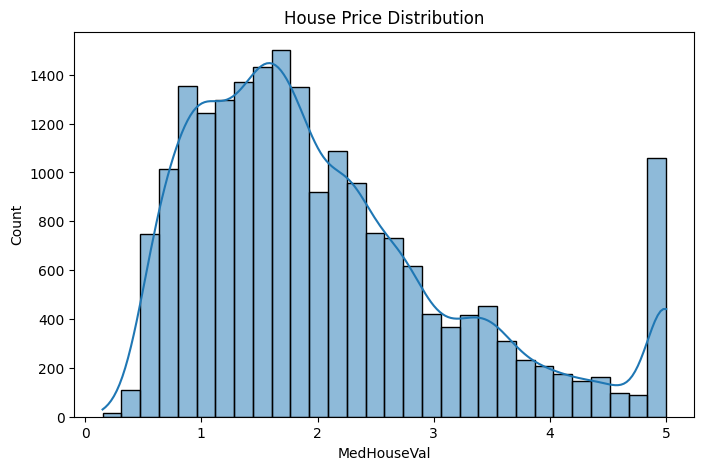

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['MedHouseVal'],
             bins=30,
             kde=True)

plt.title("House Price Distribution")
plt.show()

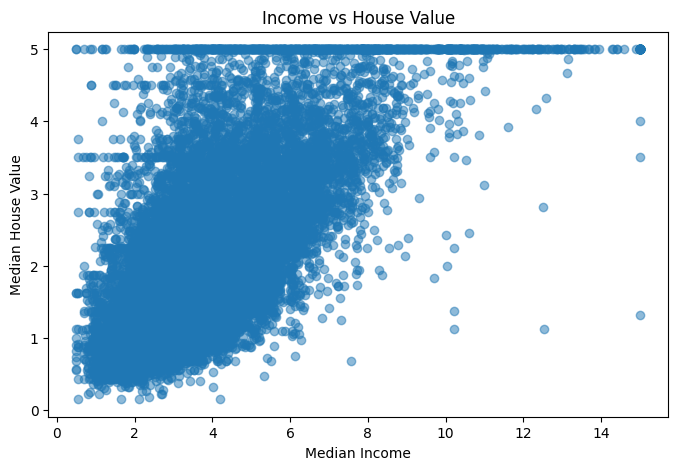

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(df['MedInc'],
            df['MedHouseVal'],
            alpha=0.5)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.title("Income vs House Value")

plt.show()

In [16]:
     # Independent variables

X = df.drop("MedHouseVal", axis=1)

# Dependent variable

y = df["MedHouseVal"]

In [17]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


In [20]:
# Create Linear Regression model

model = LinearRegression()

# Train model

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [21]:
# Predict on test data

y_pred = model.predict(X_test)

# Display first 10 predictions

print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [22]:
# MAE

mae = mean_absolute_error(y_test, y_pred)

# RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 Score

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.5332001304956555
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451


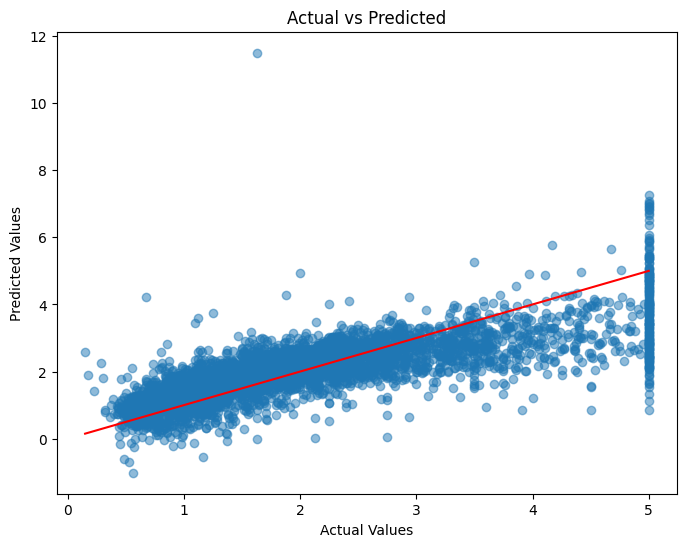

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,
            y_pred,
            alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

# Ideal line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

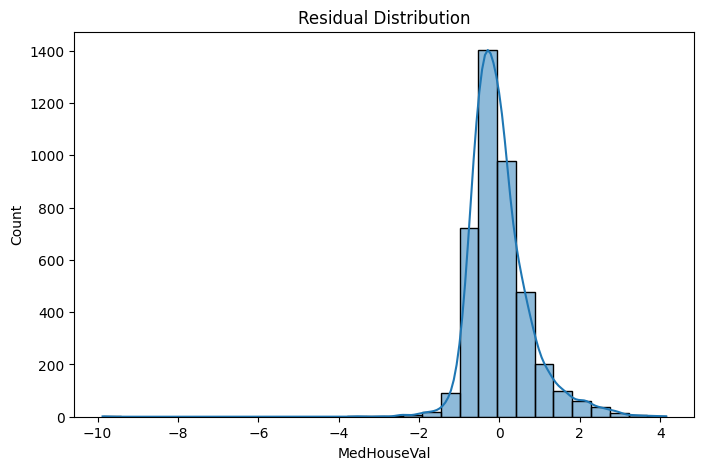

In [24]:
# Residuals

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals,
             bins=30,
             kde=True)

plt.title("Residual Distribution")

plt.show()

In [25]:
# Model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient',
                         ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [26]:
# Save model

joblib.dump(model, 'linear_regression_model.pkl')

print("Model saved successfully")

Model saved successfully


In [27]:
# Load model

loaded_model = joblib.load('linear_regression_model.pkl')

print("Model loaded successfully")

Model loaded successfully


In [28]:
# Example new data

new_data = [[8.3252,
             41,
             6.984127,
             1.02381,
             322,
             2.555556,
             37.88,
             -122.23]]

prediction = loaded_model.predict(new_data)

print("Predicted House Price:", prediction[0])

Predicted House Price: 4.151943055154298


C:\Users\divya\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
import numpy as np

# Load model
model = joblib.load('linear_regression_model.pkl')

print("California House Price Predictor")

MedInc = float(input("Median Income: "))
HouseAge = float(input("House Age: "))
AveRooms = float(input("Average Rooms: "))
AveBedrms = float(input("Average Bedrooms: "))
Population = float(input("Population: "))
AveOccup = float(input("Average Occupancy: "))
Latitude = float(input("Latitude: "))
Longitude = float(input("Longitude: "))

data = np.array([[MedInc,
                  HouseAge,
                  AveRooms,
                  AveBedrms,
                  Population,
                  AveOccup,
                  Latitude,
                  Longitude]])

prediction = model.predict(data)

print("\nPredicted House Price:", prediction[0])